# Politika Gradyanı (REINFORCE) ile CartPole'u Dengede Tutmak

**İş Problemi:** Üzerine mafsallı bir direk tutturulmuş bir arabayı, sadece sola/sağa iterek devirmeden
dengede tutmak. Durum uzayı (araba konumu, hızı, direk açısı, açısal hızı) SÜREKLİ olduğu için
[21.2.2](../21.2-Q_Learning/21.2.2_q_learning_frozenlake.ipynb)'deki gibi bir Q-tablosu kuramıyoruz
(bkz. [21.3.1-Policy_Gradient_ve_DQN.pdf](21.3.1-Policy_Gradient_ve_DQN.pdf), Bölüm 1 ve 4.1). Bu yüzden
politikayı π(a\|s) doğrudan, ağırlıkları öğrenilen parametrik bir fonksiyon olarak temsil edip REINFORCE
algoritmasıyla eğitiyoruz.

**Not:** Bu uygulama, harici bir derin öğrenme çerçevesi (PyTorch/TensorFlow) gerektirmemesi ve
REINFORCE'un matematiğini adım adım görünür kılması için, politika ağını tamamen NumPy ile, tek katmanlı
doğrusal + softmax bir model olarak sıfırdan kurar. PDF dosyasının Bölüm 3'ünde anlatılan DQN'e
(deneyim tekrarı + hedef ağ + derin sinir ağı) geçmek isteyenler için bu notebook, aynı kavramsal
çerçeveyi (fonksiyon yaklaşıklama) daha basit bir modelle gösterir.

Gerekli kütüphaneyi kurmak için: `pip install gymnasium`

## 1. Ortamın Kurulumu ve Politika Ağının Tanımlanması

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action="ignore")

np.random.seed(42)

In [2]:
env = gym.make("CartPole-v1")

n_inputs = env.observation_space.shape[0]   # 4 (konum, hız, direk açısı, açısal hız)
n_actions = env.action_space.n              # 2 (sola it, sağa it)

print(f"Durum boyutu: {n_inputs}, Eylem sayısı: {n_actions}")

Durum boyutu: 4, Eylem sayısı: 2


In [3]:
def softmax(x):
    # Sayısal kararlılık için önce maksimumu çıkarıyoruz (overflow'u önler).
    e_x = np.exp(x - np.max(x))
    return e_x / np.sum(e_x)


def policy_forward(state, W):
    """Durumu girip, her eylem için seçilme olasılığını döndürür: pi_theta(a|s)."""
    logits = state @ W          # (n_inputs,) @ (n_inputs, n_actions) -> (n_actions,)
    probs = softmax(logits)
    return probs


def discounted_returns(rewards, gamma):
    """Bir epizottaki her adım için G_t = r(t+1) + gamma*r(t+2) + ... değerini geriye doğru hesaplar
    (bkz. 21.1.1-Pekiştirmeli_Öğrenmeye_Giriş.pdf, Bölüm 3.2)."""
    G = np.zeros(len(rewards))
    running_sum = 0.0
    for t in reversed(range(len(rewards))):
        running_sum = rewards[t] + gamma * running_sum
        G[t] = running_sum
    return G

## 2. Hiperparametreler

In [4]:
alpha = 0.02          # Öğrenme oranı
gamma = 0.99           # İndirim faktörü
n_episodes = 1200

# Politika ağının ağırlıkları: (n_inputs, n_actions) boyutunda, küçük rastgele değerlerle başlatılır.
W = np.random.randn(n_inputs, n_actions) * 0.01

## 3. Eğitim Döngüsü (REINFORCE)

Fikir: bir epizot baştan sona oynanır; epizot sonunda her adımda alınan eylemin, epizotun toplam
getirisine (G_t) ne kadar katkı sağladığı hesaplanır; getirisi yüksek epizotlarda seçilen eylemlerin
olasılığı artırılır (bkz. 21.3.1-Policy_Gradient_ve_DQN.pdf, Bölüm 2).

In [5]:
episode_lengths = []

for episode in range(n_episodes):
    state, _ = env.reset()
    states, actions, rewards = [], [], []

    done = False
    while not done:
        probs = policy_forward(state, W)
        action = np.random.choice(n_actions, p=probs)   # Politikadan örnekleme (stokastik politika)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)

        state = next_state

    episode_lengths.append(len(rewards))

    # Epizot bitti: artık G_t'yi hesaplayıp ağırlıkları güncelleyebiliriz.
    returns = discounted_returns(rewards, gamma)

    # Varyans azaltma (baseline): getirileri epizot içinde normalize etmek, öğrenmeyi kararlı hale
    # getirir ama yansız (unbiased) bir gradyan tahmincisi olmaya devam eder.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    grad_W = np.zeros_like(W)
    for state_t, action_t, G_t in zip(states, actions, returns):
        probs_t = policy_forward(state_t, W)
        one_hot = np.zeros(n_actions)
        one_hot[action_t] = 1.0
        # d(log pi_theta(a_t|s_t)) / dW  =  outer(state_t, one_hot - probs_t)
        # (softmax + cross-entropy'nin standart gradyan türevi)
        grad_log_pi = np.outer(state_t, one_hot - probs_t)
        grad_W += grad_log_pi * G_t

    # theta <- theta + alpha * grad_W  (bkz. 21.3.1-Policy_Gradient_ve_DQN.pdf, Bölüm 2.1 formülü)
    W += alpha * grad_W

    if (episode + 1) % 100 == 0:
        avg_len = np.mean(episode_lengths[-100:])
        print(f"Epizot {episode + 1}/{n_episodes} - Son 100 epizotun ortalama süresi: {avg_len:.1f} adım")

print("Eğitim tamamlandı.")

Epizot 100/1200 - Son 100 epizotun ortalama süresi: 53.1 adım


Epizot 200/1200 - Son 100 epizotun ortalama süresi: 141.5 adım


Epizot 300/1200 - Son 100 epizotun ortalama süresi: 210.3 adım


Epizot 400/1200 - Son 100 epizotun ortalama süresi: 246.2 adım


Epizot 500/1200 - Son 100 epizotun ortalama süresi: 332.9 adım


...

Epizot 800/1200 - Son 100 epizotun ortalama süresi: 414.4 adım


Epizot 900/1200 - Son 100 epizotun ortalama süresi: 458.0 adım


Epizot 1000/1200 - Son 100 epizotun ortalama süresi: 460.1 adım


Epizot 1100/1200 - Son 100 epizotun ortalama süresi: 493.1 adım


Epizot 1200/1200 - Son 100 epizotun ortalama süresi: 479.9 adım
Eğitim tamamlandı.


## 4. Öğrenme Performansının Görselleştirilmesi

Epizot uzunluğu = direğin kaç adım boyunca ayakta kaldığı (CartPole'da her adım +1 ödül verir). Bu
uzunluğun eğitim boyunca artması, politikanın gerçekten öğrendiğinin doğrudan kanıtıdır.

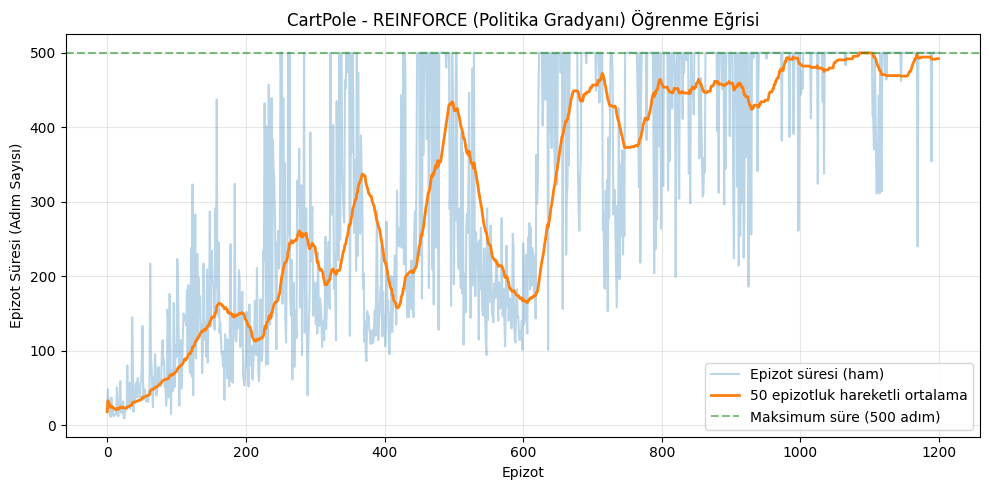

İlk 100 epizotun ortalama süresi: 53.1 adım
Son 100 epizotun ortalama süresi: 479.9 adım


In [6]:
window = 50
moving_avg = [
    np.mean(episode_lengths[max(0, i - window):i + 1])
    for i in range(len(episode_lengths))
]

plt.figure(figsize=(10, 5))
plt.plot(episode_lengths, alpha=0.3, label="Epizot süresi (ham)")
plt.plot(moving_avg, linewidth=2, label=f"{window} epizotluk hareketli ortalama")
plt.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Maksimum süre (500 adım)")
plt.title("CartPole - REINFORCE (Politika Gradyanı) Öğrenme Eğrisi")
plt.xlabel("Epizot")
plt.ylabel("Epizot Süresi (Adım Sayısı)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"İlk 100 epizotun ortalama süresi: {np.mean(episode_lengths[:100]):.1f} adım")
print(f"Son 100 epizotun ortalama süresi: {np.mean(episode_lengths[-100:]):.1f} adım")

## 5. Öğrenilmiş Politikayla Test Etme

In [7]:
test_episodes = 20
test_lengths = []

for _ in range(test_episodes):
    state, _ = env.reset()
    done = False
    steps = 0
    while not done:
        probs = policy_forward(state, W)
        action = np.argmax(probs)   # Test aşamasında artık keşif yok, en olası eylem seçilir (sömürü).
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1
    test_lengths.append(steps)

print(f"Test sonucu ({test_episodes} epizot, tamamen öğrenilen politika ile): "
      f"ortalama {np.mean(test_lengths):.1f} adım (maksimum 500)")

env.close()

Test sonucu (20 epizot, tamamen öğrenilen politika ile): ortalama 500.0 adım (maksimum 500)


## Sonuç

Politika, eğitimin başında ortalama birkaç düzine adım sonra düşerken, eğitim sonunda direği maksimum
süre boyunca (500 adım) dengede tutmayı öğrendi — hem de hiçbir Q-tablosu ya da derin öğrenme çerçevesi
kullanmadan, tamamen NumPy ile yazılmış tek katmanlı bir politika ağıyla. Bu, fonksiyon yaklaşıklamalı
pekiştirmeli öğrenmenin (bkz. 21.3.1-Policy_Gradient_ve_DQN.pdf) sürekli durum uzaylarında neden gerekli
ve etkili olduğunun somut kanıtıdır.

Modülü tamamlamak için: [21.4.1-Genel_Tekrar_İçin_Sorular.pdf](../21.4-Genel_Tekrar_Soruları/21.4.1-Genel_Tekrar_İçin_Sorular.pdf)